In [1]:
import torch

torch.cuda.empty_cache()

In [2]:
# -*- coding: utf-8 -*-
from dreal import *
# from Functions import *
import torch 
import torch.nn.functional as F
import numpy as np
import timeit 
import matplotlib.pyplot as plt
import torch.nn as nn
import random

from matplotlib import cm

In [3]:
torch.manual_seed(42)

random.seed()



In [4]:
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [5]:
numerical_x = torch.Tensor(500, 2).uniform_(-6, 6).float()
numerical_x = numerical_x.to(device)  

In [6]:
def checkSMTconstraints(vars,a_learnt,divergence_learnt, ball_lb, ball_ub, config, epsilon=0):
    """ Check the SMT constraints for the given variables and learnt parameters. """
    ball = Expression(0)

    # construct ball constraint
    for i in range(len(vars)):
        ball += vars[i]**2
    ball_in_bound = logical_and(ball >= ball_lb, ball <= ball_ub)

    # condition on a
    a_condition = a_learnt >= 0
    divergence_condition = divergence_learnt > 0
    stability_condition = logical_and(
        logical_imply(ball_in_bound, divergence_condition),
        logical_imply(ball_in_bound, a_condition)
    )

    # check satisfiability of the negation of the condition
    return CheckSatisfiability(logical_not(stability_condition), config)


def AddCounterexamples(x, CE, N, device):
    """
    Adds counterexamples to the sample set `x`.
    
    Args:
        x: Existing tensor of samples.
        CE: Counterexample intervals from `Checkdivergence`.
        N: Number of nearby points to add for each counterexample.
        device: Device where tensors are stored (e.g., `cuda:1`).

    Returns:
        Updated tensor with counterexamples added.
    """
    nearby = []
    for i in range(CE.size()):
        lb = CE[i].lb()
        ub = CE[i].ub()
        nearby_ = np.random.uniform(lb, ub, N)  # Generate nearby points
        nearby.append(nearby_)
    
    for i in range(N):
        n_pt = []
        for j in range(x.shape[1]):
            n_pt.append(nearby[j][i])  # Collect one point from each dimension
        # Add the point to `x` on the correct device
        n_pt_tensor = torch.tensor([n_pt], dtype=torch.float32, device=device)
        x = torch.cat((x, n_pt_tensor), dim=0)
        x= torch.unique(x, dim=0)

    return x, n_pt_tensor

# Dynamical system:
The system of interest is:
\begin{align*}
    \begin{bmatrix}
        \dot{x}_1 \\
        \dot{x}_2
    \end{bmatrix}= 
    \begin{bmatrix}
        x_2-x_1^3+x_1^2\\
        0
    \end{bmatrix} + \begin{bmatrix}
        0\\
        1
    \end{bmatrix}u
\end{align*}


In [7]:
import math

def f_value(f_val, g_val, u):
    """
    The dynamical system is defined as f(x)+g(x)u
    where f(x) and g(x) are functions of x and u is the control
    input. This function returns the value of the dynamical system
    at x with control input u.
    """
    return f_val + g_val * u

def f(x):
    # fill this later according to dynamical system
    # ensure the return is like torch.tensor([1,2])
    val = torch.tensor([x[1]-x[0]**3+x[0]**2, 0],device=device)
    return val
def g(x):
    # fill this later according to dynamical system
    # ensure the return is like torch.tensor([1,2])
    return torch.tensor([0*x[0], 1], device=device)



In [8]:
class polynomial_net(nn.Module):
    """ this class is used to define the neural network which we intent to approximate a polynomial function"""
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(polynomial_net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)

class polynomial_net_bias_Zero(nn.Module):
    """ this class is used to define the neural network which we intent to approximate a polynomial function"""
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(polynomial_net_bias_Zero, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)  # set bias to zero
                layer.bias.requires_grad = False  # freeze bias to stay zero


    def forward(self, x):
        return self.net(x)
    
class numerator_polynomial_net(nn.Module):
    """ this class is used to define the neural network which we intent to approximate a polynomial function"""
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(numerator_polynomial_net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)

class FixedDenominatorNet(nn.Module):
    def __init__(self):
        super(FixedDenominatorNet, self).__init__()

    def forward(self, x):
        # Compute e^{||x||^2}
        norm_squared = torch.sum(x ** 2, dim=1, keepdim=True)  
        return torch.exp(norm_squared)
     
class GammaFunctionNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(GammaFunctionNet, self).__init__()
        self.linear_layer = nn.Linear(input_dim, output_dim)
        
        # Initialize weights to zero and bias to zero (or any desired value)
        nn.init.constant_(self.linear_layer.weight, 0)
        nn.init.constant_(self.linear_layer.bias, 0)

        # Freeze weights to ensure they cannot be updated
        self.linear_layer.weight.requires_grad = False

    def forward(self, x):
        # Directly return the bias as output
        return self.linear_layer.bias



In [9]:
def gradient_at_given_function(func,x):
    """ The function returns the gradient of given function at x"""
    # Ensure x requires gradients
    x = x.clone().detach().requires_grad_(True)
    
   # Compute the output of the function
    output = func(x.unsqueeze(0))  # Add batch dimension (shape: [1, input_dim])
    
    # Extract scalar from output tensor
    output = output.squeeze()  # Remove batch and channel dimensions (shape: ())
    
    # Ensure the function returns a scalar
    if output.dim() != 0:
        raise ValueError(f"The function must return a scalar value, but got shape {output.shape}.")
    
    # Compute the gradient
    grad = torch.autograd.grad(outputs=output, inputs=x, create_graph=True)[0]
    
    return grad
import torch

def gradient_at_given_function_special_b(func, x):
    """
    This function returns the gradient of f^T f at x.
    Here, f: R^n → R^d, and we wish to return the gradient of f^T f at x.
    
    The idea:
    - Compute output = f(x), which is a vector in R^d.
    - Compute squared norm: output_norm_squared = ||f(x)||^2 = f^T f.
    - Compute gradient of output_norm_squared w.r.t. x.
    """
    # Ensure x requires gradients
    x = x.clone().detach().requires_grad_(True)
    
    # Compute f(x)
    output = func(x.unsqueeze(0))  # Add batch dimension (shape: [1, input_dim])
    
    # Remove batch dimension to get shape [d]
    output = output.squeeze(0)
    
    # Check that output is a vector (1D)
    if output.dim() != 1:
        raise ValueError(f"The function must return a vector value (shape [d]), but got shape {output.shape}.")
    
    # Compute f^T f = ||f(x)||^2
    output_norm_squared = torch.sum(output ** 2)
    
    # Compute the gradient w.r.t. x
    grad = torch.autograd.grad(outputs=output_norm_squared, inputs=x, create_graph=True)[0]
    
    return grad



def div_f(x):
    # fill this later according to dynamical system
    # ensure the return is like torch.tensor(1)
    term = -3*(x[0]**2 )+ 2*x[0]
    return torch.tensor(term, device=device)

def div_g(x):
    # fill this later according to dynamical system
    # ensure the return is like torch.tensor(1)
    term = 0
    return torch.tensor(term, device=device)

def control_density_risk(x, f_fun, g_fun, a_fun, b_fun, c_fun):
    ret_val = []
    for i in range(x.shape[0]):
        divergence_at_f = div_f(x[i])
        divergence_at_g = div_g(x[i])
        grad_at_a = gradient_at_given_function(a_fun, x[i])
        grad_at_c = gradient_at_given_function(c_fun, x[i])
        grad_at_b = gradient_at_given_function_special_b(b_fun, x[i])
        # square root of x^Tx
        
        a_vals = a_fun(x[i])
        # b_vals = b_fun(x[i])
        c_vals = c_fun(x[i])
        f_vals = f_fun(x[i])
        g_vals = g_fun(x[i])
        term1 = a_vals * divergence_at_f + divergence_at_g * c_vals + grad_at_a.T @ f_vals + grad_at_c.T @ g_vals
        term2 = (2 * x[i] + grad_at_b) @ (f_vals * a_vals + g_vals * c_vals)
        term = term1 - term2
        ret_val.append(term)
    ret_val = torch.stack(ret_val)
    return ret_val 



In [10]:
def control_density_loss(x, f_fun, g_fun, a_fun, b_fun, c_fun, gamma_fun, lambda_center=1, lambda_decay=1):
    """
    Compute the control density loss with additional center and decay regularization.

    Args:
        x: Input tensor.
        f_fun: Function representing f(x).
        g_fun: Function representing g(x).
        a_fun: Function representing a(x).
        b_fun: Function representing b(x).
        c_fun: Function representing c(x).
        gamma_fun: Function representing gamma(x).
        lambda_center: Weight for center-maximizing term.
        lambda_decay: Weight for decay-penalizing term.

    Returns:
        Total control density loss value.
    """
    divergence = control_density_risk(x, f_fun, g_fun, a_fun, b_fun, c_fun)
    loss = F.relu(gamma_fun(x) - divergence).mean()
    a_loss = F.relu(-a_fun(x)).mean()
    gamma_loss = F.relu(-gamma_fun(x)).mean()
      
    total_loss = loss + a_loss + gamma_loss 
    return total_loss


In [11]:
class activSymbolicNN:
    """
    A helper class to convert neural networks to symbolic expressions for dReal.
    """
    def __init__(self, net):
        """Initialize with a PyTorch neural network"""
        self.weights = []
        self.biases = []
        self.extract_params(net)

    def extract_params(self, net):
        """Extract weights and biases from PyTorch network"""
        for layer in net.net:
            if isinstance(layer, nn.Linear):
                self.weights.append(layer.weight.detach().cpu().numpy())
                if layer.bias is not None:
                    self.biases.append(layer.bias.detach().cpu().numpy())

    def forward_symbolic(self, vars):
        """
        Compute symbolic forward pass.
        Args:
            vars: List of dReal Variables
        Returns:
            Symbolic expression for network output
        """
        z = vars
        for i in range(len(self.weights)):
            # Linear transformation
            z = self._linear_symbolic(z, self.weights[i], self.biases[i])
            # # Apply tanh activation
            # z = [tanh(zi) for zi in z]
            # Apply sigmoid activation
            z = [(1/(1 + exp(-zi))) for zi in z]
        
        # # Final linear layer without activation
        # z = self._linear_symbolic(z, self.weights[-1], self.biases[-1])
        return z

    def _linear_symbolic(self, x, weight, bias):
        """
        Compute symbolic linear transformation.
        Args:
            x: Input symbolic expressions
            weight: Weight matrix
            bias: Bias vector
        Returns:
            List of symbolic expressions
        """
        out = []
        for i in range(weight.shape[0]):  # For each output dimension
            expr = bias[i]
            for j in range(weight.shape[1]):  # For each input dimension
                expr += weight[i,j] * x[j]
            out.append(expr)
        return out


In [12]:
class SymbolicNN:
    """
    A helper class to convert neural networks to symbolic expressions for dReal.
    """
    def __init__(self, net):
        """Initialize with a PyTorch neural network"""
        self.weights = []
        self.biases = []
        self.extract_params(net)

    def extract_params(self, net):
        """Extract weights and biases from PyTorch network"""
        for layer in net.net:
            if isinstance(layer, nn.Linear):
                self.weights.append(layer.weight.detach().cpu().numpy())
                if layer.bias is not None:
                    self.biases.append(layer.bias.detach().cpu().numpy())

    def forward_symbolic(self, vars):
        """
        Compute symbolic forward pass.
        Args:
            vars: List of dReal Variables
        Returns:
            Symbolic expression for network output
        """
        z = vars
        for i in range(len(self.weights) - 1):
            # Linear transformation
            z = self._linear_symbolic(z, self.weights[i], self.biases[i])
            # Apply tanh activation
            z = [tanh(zi) for zi in z]
            # # Apply sigmoid activation
            # z = [(1/(1 + exp(-zi))) for zi in z]
        
        # Final linear layer without activation
        z = self._linear_symbolic(z, self.weights[-1], self.biases[-1])
        return z

    def _linear_symbolic(self, x, weight, bias):
        """
        Compute symbolic linear transformation.
        Args:
            x: Input symbolic expressions
            weight: Weight matrix
            bias: Bias vector
        Returns:
            List of symbolic expressions
        """
        out = []
        for i in range(weight.shape[0]):  # For each output dimension
            expr = bias[i]
            for j in range(weight.shape[1]):  # For each input dimension
                expr += weight[i,j] * x[j]
            out.append(expr)
        return out


In [13]:
def candidate_constraint_learnt(vars,a_fun,b_fun,c_fun):
    """
    Construct candidate constraints for the learnt functions.
    
    Args:
        vars: List of dReal Variables
        a_fun: Function representing a(x).
        b_fun: Function representing b(x).
        c_fun: Function representing c(x).

    Returns:
        Symbolic expression for the candidate constraint.
    """
    a_sym = activSymbolicNN(a_fun).forward_symbolic(vars)[0]
    b_sym = SymbolicNN(b_fun).forward_symbolic(vars)
    c_sym = SymbolicNN(c_fun).forward_symbolic(vars)[0]

    # b_sym = ||b_sym||^2
    b_sym = sum([bi**2 for bi in b_sym])
    # write f and g in terms of val
    f_val = [vars[1]-vars[0]**3+vars[0]**2, 0]
    # print("f_val: ", f_val)
    g_val = [0*vars[0],1]
    # print("g_val: ", g_val)
    f_div = - 3 * (vars[0]**2) + 2 * vars[0]
    g_div = 0 
    grad_a = [a_sym.Differentiate(vars[i]) for i in range(len(vars))]
    grad_c = [c_sym.Differentiate(vars[i]) for i in range(len(vars))]
    grad_b = [b_sym.Differentiate(vars[i]) for i in range(len(vars))]

    constraint1 = a_sym * f_div + g_div * c_sym + sum([grad_a[i] * f_val[i] for i in range(len(f_val))]) + sum([grad_c[i] * g_val[i] for i in range(len(g_val))])
  
    scaled_vars = [2 * var_i for var_i in vars]
    constraint2 = [scaled_vars[i] + grad_b[i] for i in range(len(vars))]

    constraint2 = sum([constraint2[i] * (f_val[i] * a_sym + g_val[i] * c_sym) for i in range(len(f_val))])  
    constraint = constraint1 - constraint2
    return a_sym , constraint


In [14]:
config = Config()
config.use_polytope_in_forall = True
config.use_local_optimization = True
config.precision = 1e-5
epsilon = 0

ball_lb = 0.5
ball_ub = 6
x1 = Variable("x1")
x2 = Variable("x2")


In [15]:
def train_density(x,epochs=2000, lr=1e-2):
    loss_total_density = []
    # Define the neural networks
    a_net = numerator_polynomial_net(2, 4, 1).to(device)
    c_net = polynomial_net(2, 4, 1).to(device)
    b_net = polynomial_net_bias_Zero(2, 4, 2).to(device)
    gamma_net = GammaFunctionNet(2, 1).to(device)

    # Define the optimizer
    optimizer = torch.optim.RMSprop(list(a_net.parameters()) + list(c_net.parameters()) + list(b_net.parameters()) + list(gamma_net.parameters()), lr=lr)

    valid = False
    print("Training density function")
    while not valid :
        for epoch in range(epochs):
            optimizer.zero_grad()
            # compute the loss
            loss = control_density_loss(x, f, g, a_net, b_net, c_net, gamma_net)
            loss_total_density.append(loss.item())
            # backpropagation
            loss.backward()
            # update the parameters
            optimizer.step()
            
            if loss.item() == 0:
                # # Check for counterexamples
                # vars = [Variable("x1"), Variable("x2")]
                # a_learnt, divergence_learnt = candidate_constraint_learnt(vars, a_net, b_net, c_net)
                # CE = checkSMTconstraints(vars, a_learnt, divergence_learnt, ball_lb, ball_ub, config)
                # if (CE):
                #     print("Counterexample found!")
                #     x, n_pt_tensor = AddCounterexamples(x, CE, 100, device)
                # else:
                valid = True 
                print("No counterexample found.")
                break

            print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}")
            if epoch % 100 == 0:
                # Check for counterexamples
                vars = [Variable("x1"), Variable("x2")]
                a_learnt, divergence_learnt = candidate_constraint_learnt(vars, a_net, b_net, c_net)
                CE = checkSMTconstraints(vars, a_learnt, divergence_learnt, ball_lb, ball_ub, config)
                if (CE):
                    print("Counterexample found!")
                    x, n_pt_tensor = AddCounterexamples(x, CE, 100, device)
                else:
                    valid = True 
                    print("No counterexample found.")
                    break
    print(f"Final Loss: {loss.item():.4f}")
    print(f"The learned margin is {gamma_net(torch.tensor([0,0], dtype=torch.float32, device=device))}")
    return loss_total_density, a_net, b_net, c_net, gamma_net


In [16]:
def plot_results(risks, labels):
    plt.figure(figsize=(10, 6))
    for risk, label in zip(risks, labels):
        plt.plot(risk, label=label)
    plt.xlabel("Iteration")
    plt.ylabel("Risk")
    plt.title("Risk Over Iterations")
    plt.legend()
    plt.grid()
    plt.show()


In [22]:
loss_density, a_ret, b_ret, c_ret, gamma_net = train_density(numerical_x, epochs=2000, lr=1e-2)

Training density function


/tmp/ipykernel_443796/547503560.py:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(term, device=device)
/tmp/ipykernel_443796/547503560.py:82: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3697.)
  term1 = a_vals * divergence_at_f + divergence_at_g * c_vals + grad_at_a.T @ f_vals + grad_at_c.T @ g_vals


Epoch 0/2000, Loss: 0.2160
Counterexample found!
Epoch 1/2000, Loss: 0.1133
Epoch 2/2000, Loss: 0.0306
Epoch 3/2000, Loss: 0.0245
Epoch 4/2000, Loss: 0.0187
Epoch 5/2000, Loss: 0.0151
Epoch 6/2000, Loss: 0.0135
Epoch 7/2000, Loss: 0.0127
Epoch 8/2000, Loss: 0.0119
Epoch 9/2000, Loss: 0.0112
Epoch 10/2000, Loss: 0.0105
Epoch 11/2000, Loss: 0.0098
Epoch 12/2000, Loss: 0.0092
Epoch 13/2000, Loss: 0.0086
Epoch 14/2000, Loss: 0.0083
Epoch 15/2000, Loss: 0.0080
Epoch 16/2000, Loss: 0.0078
Epoch 17/2000, Loss: 0.0075
Epoch 18/2000, Loss: 0.0073
Epoch 19/2000, Loss: 0.0070
Epoch 20/2000, Loss: 0.0067
Epoch 21/2000, Loss: 0.0064
Epoch 22/2000, Loss: 0.0060
Epoch 23/2000, Loss: 0.0057
Epoch 24/2000, Loss: 0.0055
Epoch 25/2000, Loss: 0.0053
Epoch 26/2000, Loss: 0.0052
Epoch 27/2000, Loss: 0.0054
Epoch 28/2000, Loss: 0.0047
Epoch 29/2000, Loss: 0.0043
Epoch 30/2000, Loss: 0.0039
Epoch 31/2000, Loss: 0.0036
Epoch 32/2000, Loss: 0.0033
Epoch 33/2000, Loss: 0.0031
Epoch 34/2000, Loss: 0.0030
Epoch 35

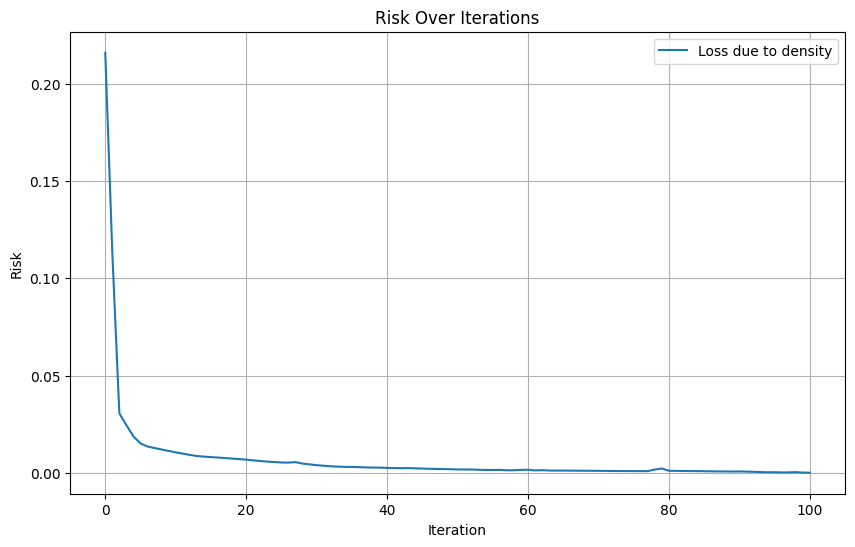

In [23]:

risks = []
risks.append(loss_density)

plot_results(risks, labels=[f"Loss due to {d}" for d in ['density']])


In [24]:
grid_size = 100
# Define grid for x1 and x2
x1 = torch.linspace(-6, 6, grid_size)
x2 = torch.linspace(-6, 6, grid_size)
x1_grid, x2_grid = torch.meshgrid(x1, x2)
grid_points = torch.stack([x1_grid.ravel(), x2_grid.ravel()], dim=1).to(device)


/home/sahilc/miniconda3/envs/dreal_env/lib/python3.8/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [25]:
rho_set = a_ret(grid_points)/ (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_ret(grid_points))**2, dim=1, keepdim=True)))


# # Compute violations set: element-wise min of rho_set and divergence_set
# violations_set = torch.minimum(rho_set, divergence_set)
violations_set = rho_set
# # Convert to binary values: 1 for violation, -1 for satisfaction
# violations_set = torch.where(violations_set <= 0, 1, -1)

# Move to CPU and convert to NumPy for visualization
violations_set = violations_set.detach().cpu().numpy().reshape(grid_size, grid_size)


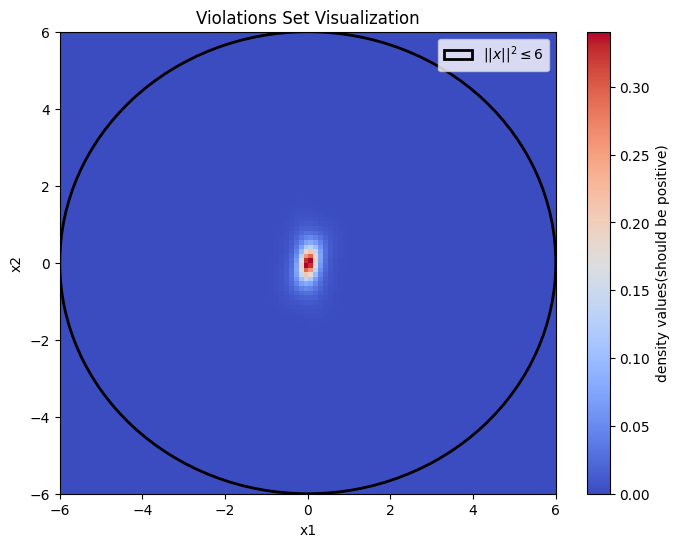

In [26]:
import matplotlib.patches as patches

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(
    violations_set,
    extent=[-6, 6, -6, 6],
    origin='lower',
    cmap='coolwarm',
    aspect='auto'
)
plt.colorbar(label="density values(should be positive)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Violations Set Visualization")

# Add a circle to the plot
circle = patches.Circle((0, 0), 6, color='black', fill=False, linewidth=2, label="$||x||^2 \leq 6$")
plt.gca().add_patch(circle)

# Add legend for the circle
plt.legend(loc='upper right')

plt.grid(False)
plt.show()


/tmp/ipykernel_443796/547503560.py:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(term, device=device)


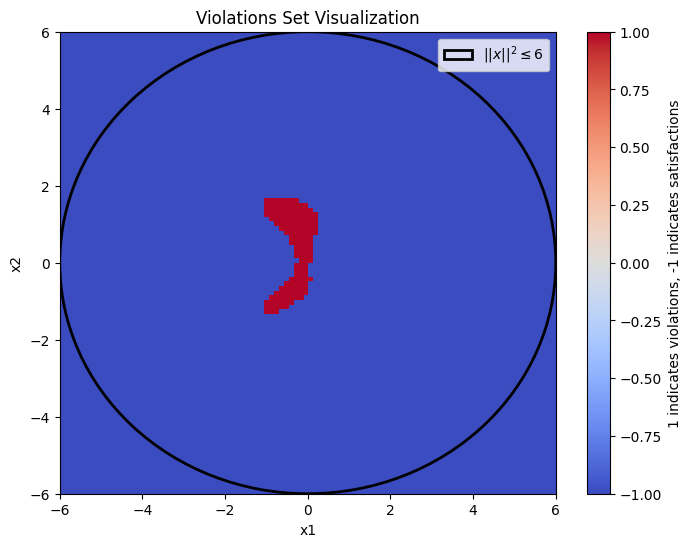

In [27]:
divergence_set = control_density_risk(grid_points, f, g, a_ret, b_ret, c_ret)

violations_set = divergence_set
# # Convert to binary values: 1 for violation, -1 for satisfaction
violations_set = torch.where(violations_set <= 0, 1, -1)

# Move to CPU and convert to NumPy for visualization
violations_set = violations_set.detach().cpu().numpy().reshape(grid_size, grid_size)




import matplotlib.patches as patches

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(
    violations_set,
    extent=[-6, 6, -6, 6],
    origin='lower',
    cmap='coolwarm',
    aspect='auto'
)
plt.colorbar(label="1 indicates violations, -1 indicates satisfactions")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Violations Set Visualization")

# Add a circle to the plot
circle = patches.Circle((0, 0), 6, color='black', fill=False, linewidth=2, label="$||x||^2 \leq 6$")
plt.gca().add_patch(circle)

# Add legend for the circle
plt.legend(loc='upper right')

plt.grid(False)
plt.show()


# Countour:

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

In [7]:
def plot_density_countours(a_nn, b_nn, c_nn, device, plot_flow=True):
    # create meshgrid
    x1 = torch.linspace(-6, 6, 100)
    x2 = torch.linspace(-6, 6, 100)
    X, Y = np.meshgrid(x1,x2)

    # Convert to torch tensor
    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), dtype=torch.float32).to(device)

    # compute the modified density function
    with torch.no_grad():
        rho_set = a_nn(grid_points) / (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)))
        rho_set = rho_set.squeeze()
        rho_set = rho_set.cpu().numpy().reshape(X.shape)
    # plot the density function
    fig, ax = plt.subplots(figsize=(8, 6))
    # contours = ax.contour(X, Y, rho_set, levels=10, colors='k')
    filled_contours = ax.contourf(X, Y, rho_set, levels=10, alpha=0.3,cmap=cm.coolwarm)
    plt.colorbar(filled_contours, label='Density Value')

    if plot_flow:
        # create coarser grid for flow field
        x1_flow = np.linspace(-6, 6, 20)
        x2_flow = np.linspace(-6, 6, 20)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]), dtype=torch.float32).to(device)

        # evaluate control policy u
        with torch.no_grad():
            u_values = c_nn(flow_points) / a_nn(flow_points)
               
        # Calculate vector field
        DX = np.zeros_like(X_flow)
        DY = np.zeros_like(Y_flow)
        
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                
                # Compute flow: f(x) + g(x)u
                flow = f_val + g_val * u
                DX[i, j] = flow[0].cpu().numpy()
                DY[i, j] = flow[1].cpu().numpy()
        
        # Normalize vectors for better visualization
        magnitude = np.sqrt(DX**2 + DY**2)
        DX = DX / magnitude
        DY = DY / magnitude
        
        # Plot flow field
        ax.streamplot(X_flow, Y_flow, DX, DY, color='gray', linewidth=0.5,
                     density=1.0, arrowstyle='-|>', arrowsize=1.5)
    
    # Add valid region circle
    circle = plt.Circle((0, 0), 6, color='r', fill=False, linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)
    
    # Customize plot
    ax.set_xlabel('Angle (rad)')
    ax.set_ylabel('Angular velocity')
    ax.set_title('Density Function Contours with Flow Field')
    ax.legend()
    ax.grid(True)
    
    plt.show()
    
    return fig, ax





    

In [ ]:

# Call the function to plot density contours and flow field
plot_density_countours(a_ret, b_ret, c_ret, device, plot_flow=True)



In [8]:
torch.save(a_ret.state_dict(), 'learnt_a_control_density_example_1.pth')
torch.save(b_ret.state_dict(), 'learnt_b_control_density_example_1.pth')
torch.save(c_ret.state_dict(), 'learnt_c_control_density_example_1.pth')

NameError: name 'a_ret' is not defined

# With new random initialization

In [31]:
# get some fresh data 
torch.manual_seed(7)
random.seed()
numerical_x = torch.Tensor(500, 2).uniform_(-6, 6).float()
numerical_x = numerical_x.to(device)

loss_density, a_ret, b_ret, c_ret, gamma_net = train_density(numerical_x, epochs=2000, lr=1e-2)

Training density function


/tmp/ipykernel_443796/547503560.py:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(term, device=device)


Epoch 0/2000, Loss: 0.0920
Counterexample found!
Epoch 1/2000, Loss: 0.1548
Epoch 2/2000, Loss: 0.2612
Epoch 3/2000, Loss: 0.0527
Epoch 4/2000, Loss: 0.0381
Epoch 5/2000, Loss: 0.0322
Epoch 6/2000, Loss: 0.0282
Epoch 7/2000, Loss: 0.0348
Epoch 8/2000, Loss: 0.0729
Epoch 9/2000, Loss: 0.0520
Epoch 10/2000, Loss: 0.0449
Epoch 11/2000, Loss: 0.0406
Epoch 12/2000, Loss: 0.0370
Epoch 13/2000, Loss: 0.0340
Epoch 14/2000, Loss: 0.0312
Epoch 15/2000, Loss: 0.0289
Epoch 16/2000, Loss: 0.0271
Epoch 17/2000, Loss: 0.0255
Epoch 18/2000, Loss: 0.0241
Epoch 19/2000, Loss: 0.0229
Epoch 20/2000, Loss: 0.0218
Epoch 21/2000, Loss: 0.0209
Epoch 22/2000, Loss: 0.0201
Epoch 23/2000, Loss: 0.0193
Epoch 24/2000, Loss: 0.0187
Epoch 25/2000, Loss: 0.0179
Epoch 26/2000, Loss: 0.0174
Epoch 27/2000, Loss: 0.0171
Epoch 28/2000, Loss: 0.0167
Epoch 29/2000, Loss: 0.0163
Epoch 30/2000, Loss: 0.0159
Epoch 31/2000, Loss: 0.0155
Epoch 32/2000, Loss: 0.0151
Epoch 33/2000, Loss: 0.0147
Epoch 34/2000, Loss: 0.0144
Epoch 35

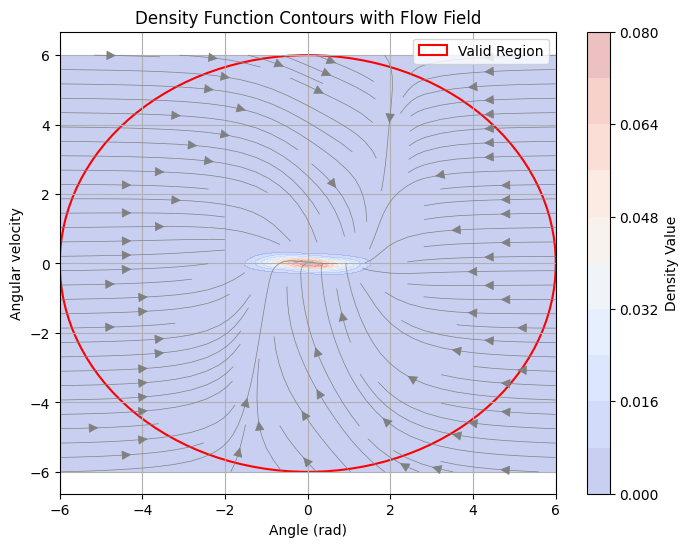

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Density Function Contours with Flow Field'}, xlabel='Angle (rad)', ylabel='Angular velocity'>)

In [33]:
plot_density_countours(a_ret, b_ret, c_ret, device, plot_flow=True)

In [34]:
torch.save(a_ret.state_dict(), 'learnt_a_control_density1_example_1.pth')
torch.save(b_ret.state_dict(), 'learnt_b_control_density1_example_1.pth')
torch.save(c_ret.state_dict(), 'learnt_c_control_density1_example_1.pth')

# Plan of the day:

Once the path files are saved, may be no need to learn them again. Thus, we will just mix the controllers and get a hold on it. Controllers to mix:
1. learned from networks
2. analytical solution from prajna and rantzer's paper

In [18]:
# Define Model dimensions
INPUT_DIM = 2 
HIDDEN_DIM_A = 4
HIDDEN_DIM_B = 4
HIDDEN_DIM_C = 4

# Output dimension
A_OUTPUT_DIM = 1
B_OUTPUT_DIM = 2
C_OUTPUT_DIM = 1


In [19]:
# LOAD THE TRAINED MODEL weights for u_1 and \rho_1
# LOAD THE TRAINED MODEL weights for u_1 and \rho_1

a_net = numerator_polynomial_net(INPUT_DIM, HIDDEN_DIM_A, A_OUTPUT_DIM).to(device)
# Add map_location
a_net.load_state_dict(torch.load('Model_Paths/learnt_a_control_density_example_1.pth', map_location=device))
a_net.eval()

b_net = polynomial_net_bias_Zero(INPUT_DIM, HIDDEN_DIM_B, B_OUTPUT_DIM).to(device)
# Add map_location
b_net.load_state_dict(torch.load('Model_Paths/learnt_b_control_density_example_1.pth', map_location=device))
b_net.eval()

c_net = polynomial_net(INPUT_DIM, HIDDEN_DIM_C, C_OUTPUT_DIM).to(device)
# Add map_location
c_net.load_state_dict(torch.load('Model_Paths/learnt_c_control_density_example_1.pth', map_location=device))
c_net.eval()

# load the second model
a_net1 = numerator_polynomial_net(INPUT_DIM, HIDDEN_DIM_A, A_OUTPUT_DIM).to(device)
# Add map_location
a_net1.load_state_dict(torch.load('Model_Paths/learnt_a_control_density1_example_1.pth', map_location=device))
a_net1.eval()

b_net1 = polynomial_net_bias_Zero(INPUT_DIM, HIDDEN_DIM_B, B_OUTPUT_DIM).to(device)
# Add map_location
b_net1.load_state_dict(torch.load('Model_Paths/learnt_b_control_density1_example_1.pth', map_location=device))
b_net1.eval()

c_net1 = polynomial_net(INPUT_DIM, HIDDEN_DIM_C, C_OUTPUT_DIM).to(device)
# Add map_location
c_net1.load_state_dict(torch.load('Model_Paths/learnt_c_control_density1_example_1.pth', map_location=device))
c_net1.eval()


/tmp/ipykernel_3711846/4267656991.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  a_net.load_state_dict(torch.load('Model_Paths/learnt_a_control_density_example_1.pth', 

polynomial_net(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): Tanh()
    (2): Linear(in_features=4, out_features=4, bias=True)
    (3): Tanh()
    (4): Linear(in_features=4, out_features=4, bias=True)
    (5): Tanh()
    (6): Linear(in_features=4, out_features=1, bias=True)
  )
)

/tmp/ipykernel_3711846/1822436417.py:19: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Mixed Density')


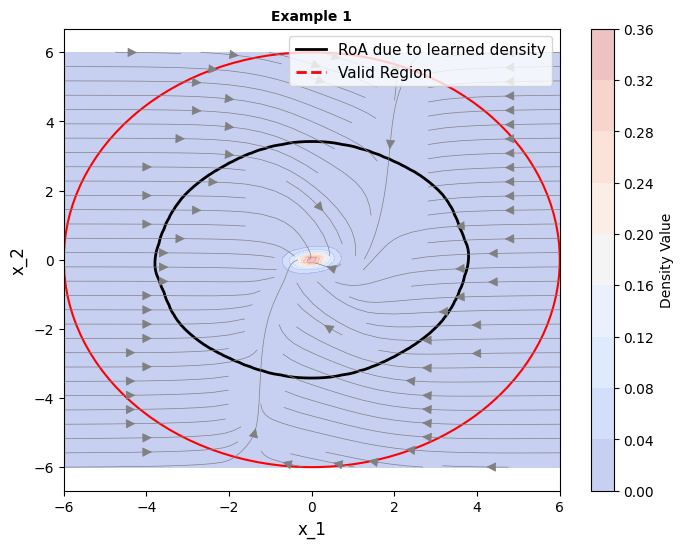

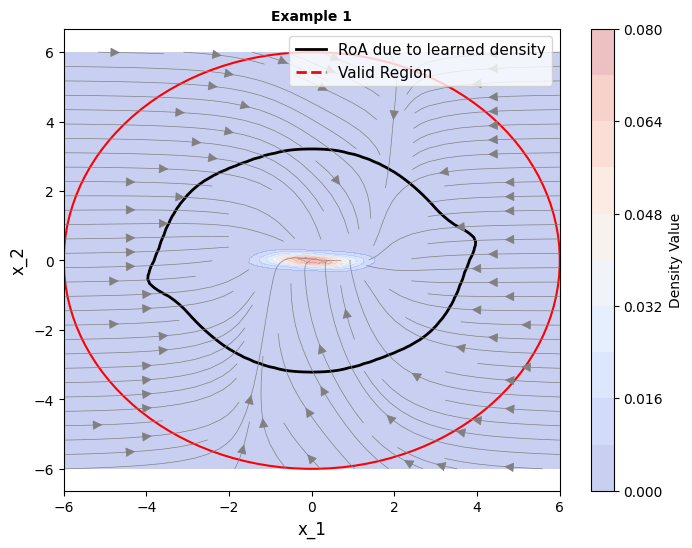

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Example 1'}, xlabel='x_1', ylabel='x_2'>)

In [20]:
def plot_density_countours(a_nn, b_nn, c_nn,density_threshold, device, plot_flow=True):
    # create meshgrid
    x1 = torch.linspace(-6, 6, 100)
    x2 = torch.linspace(-6, 6, 100)
    X, Y = np.meshgrid(x1,x2)

    # Convert to torch tensor
    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), dtype=torch.float32).to(device)

    # compute the modified density function
    with torch.no_grad():
        rho_set = a_nn(grid_points) / (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)))
        rho_set = rho_set.squeeze()
        rho_set = rho_set.cpu().numpy().reshape(X.shape)
    # plot the density function
    fig, ax = plt.subplots(figsize=(8, 6))
    # contours = ax.contour(X, Y, rho_set, levels=10, colors='k')

    ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Mixed Density')

    filled_contours = ax.contourf(X, Y, rho_set, levels=10, alpha=0.3, cmap=cm.coolwarm)
    plt.colorbar(filled_contours, label='Density Value')

    if plot_flow:
        # create coarser grid for flow field
        x1_flow = np.linspace(-6, 6, 20)
        x2_flow = np.linspace(-6, 6, 20)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]), dtype=torch.float32).to(device)

        # evaluate control policy u
        with torch.no_grad():
            u_values = c_nn(flow_points) / a_nn(flow_points)
               
        # Calculate vector field
        DX = np.zeros_like(X_flow)
        DY = np.zeros_like(Y_flow)
        
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                
                # Compute flow: f(x) + g(x)u
                flow = f_val + g_val * u
                DX[i, j] = flow[0].cpu().numpy()
                DY[i, j] = flow[1].cpu().numpy()
        
        # Normalize vectors for better visualization
        magnitude = np.sqrt(DX**2 + DY**2)
        DX = DX / magnitude
        DY = DY / magnitude
        
        # Plot flow field
        ax.streamplot(X_flow, Y_flow, DX, DY, color='gray', linewidth=0.5,
                     density=1.0, arrowstyle='-|>', arrowsize=1.5)
    
    # Add valid region circle
    circle = plt.Circle((0, 0), 6, color='r', fill=False, linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)
    
    # Customize plot
    ax.set_xlabel('x_1', fontsize=12)
    ax.set_ylabel('x_2', fontsize=12)
    ax.set_title('Example 1', fontsize=10, fontweight='bold')
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='RoA due to learned density'),
        Line2D([0], [0], color='red', linewidth=2, linestyle='--', label='Valid Region')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    
    
    
    plt.show()
    
    return fig, ax

# Call the function to plot density contours and flow field
plot_density_countours(a_net, b_net, c_net,1e-8, device, plot_flow=True)


# Call the function to plot density contours and flow field
plot_density_countours(a_net1, b_net1, c_net1,1e-8, device, plot_flow=True)





    

/tmp/ipykernel_3711846/527008580.py:21: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Mixed Density')


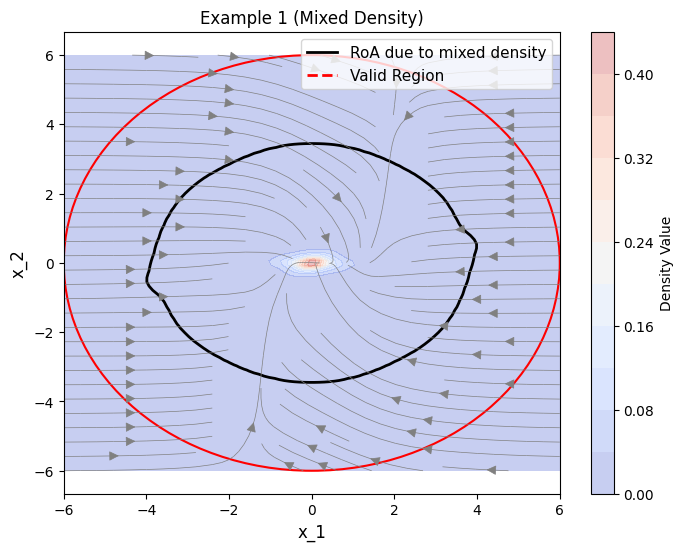

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Example 1 (Mixed Density)'}, xlabel='x_1', ylabel='x_2'>)

In [21]:
def plot_mixed_density_countours(a_nn, b_nn, c_nn,a_nn1,b_nn1,c_nn1, density_threshold, device, plot_flow=True):
    # create meshgrid
    x1 = torch.linspace(-6, 6, 100)
    x2 = torch.linspace(-6, 6, 100)
    X, Y = np.meshgrid(x1,x2)

    # Convert to torch tensor
    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), dtype=torch.float32).to(device)

    # compute the modified density function
    with torch.no_grad():
        rho_set1 = a_nn(grid_points) / (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)))
        rho_set2 =  a_nn1(grid_points) / (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_nn1(grid_points))**2, dim=1, keepdim=True)))
        rho_set =  rho_set1+rho_set2
        rho_set = rho_set.squeeze()
        rho_set = rho_set.cpu().numpy().reshape(X.shape)
    # plot the density function
    fig, ax = plt.subplots(figsize=(8, 6))
    # contours = ax.contour(X, Y, rho_set, levels=10, colors='k')

    ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Mixed Density')
    filled_contours = ax.contourf(X, Y, rho_set, levels=10, alpha=0.3, cmap=cm.coolwarm)
    plt.colorbar(filled_contours, label='Density Value')

    if plot_flow:
        # create coarser grid for flow field
        x1_flow = np.linspace(-6, 6, 20)
        x2_flow = np.linspace(-6, 6, 20)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]), dtype=torch.float32).to(device)

        # evaluate control policy u
        with torch.no_grad():
            rho_set1 = a_nn(flow_points) / (torch.exp( torch.sum(flow_points**2, dim=1, keepdim=True) + torch.sum((b_nn(flow_points))**2, dim=1, keepdim=True)))
            
            rho_set2 =  a_nn1(flow_points) / (torch.exp( torch.sum(flow_points**2, dim=1, keepdim=True) + torch.sum((b_nn1(flow_points))**2, dim=1, keepdim=True)))
            u_values1 = c_nn(flow_points) / a_nn(flow_points)
            u_values2 = c_nn1(flow_points) / a_nn1(flow_points)
            weight1 = rho_set1 / (rho_set1+rho_set2)
            weight2 = rho_set2 / (rho_set1+rho_set2)
            u_values = weight1 * u_values1 + weight2 * u_values2
               
        # Calculate vector field
        DX = np.zeros_like(X_flow)
        DY = np.zeros_like(Y_flow)
        
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                
                # Compute flow: f(x) + g(x)u
                flow = f_val + g_val * u
                DX[i, j] = flow[0].cpu().numpy()
                DY[i, j] = flow[1].cpu().numpy()
        
        # Normalize vectors for better visualization
        magnitude = np.sqrt(DX**2 + DY**2)
        DX = DX / magnitude
        DY = DY / magnitude
        
        # Plot flow field
        ax.streamplot(X_flow, Y_flow, DX, DY, color='gray', linewidth=0.5,
                     density=1.0, arrowstyle='-|>', arrowsize=1.5)
    
    # Add valid region circle
    circle = plt.Circle((0, 0), 6, color='r', fill=False, linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)
    
    # Customize plot
    ax.set_xlabel('x_1', fontsize=12)
    ax.set_ylabel('x_2', fontsize=12)
    ax.set_title('Example 1 (Mixed Density)')
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='RoA due to mixed density'),
        Line2D([0], [0], color='red', linewidth=2, linestyle='--', label='Valid Region')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    
    
    
    plt.show()
    
    return fig, ax


# Call the function to plot density contours and flow field
plot_mixed_density_countours(a_net, b_net, c_net,a_net1,b_net1,c_net1, 1e-8, device, plot_flow=True)



## get analytical controller and density

\begin{align}
    b(x)&=3x_1^2+2x_1x_2+2x_2^2, \alpha = 4\\
    u(x)&=-1.22x_1-0.57x_2-0.129x_2^3\\
    \rho(x)&= a/b^{\alpha}, u\rho = c/b^{\alpha}
\end{align}
for learning $u=c/a$, take $a=1$ and thus, $\rho(x)=1/b^\alpha, u=c$

In [34]:
# -----------------------------------------------------------------
# --- New Code Block Starts Here ---
# -----------------------------------------------------------------

from matplotlib import cm # Ensure cm is imported at the top level

# --- 1. Helper functions for the Analytical Solution ---

def analytical_density(x, device, alpha=4.0, epsilon=1e-9):
    """
    Computes the analytical density rho(x) = 1 / (b(x)^alpha)
    x: torch.tensor of shape [N, 2]
    """
    x1 = x[:, 0]
    x2 = x[:, 1]
    
    # b(x) = 3*x1^2 + 2*x1*x2 + 2*x2^2
    b_val = 3 * (x1**2) + 2 * x1 * x2 + 2 * (x2**2)
    
    # rho(x) = 1 / b(x)^alpha
    # Add epsilon for numerical stability at the origin
    rho = (1e-8) / (torch.pow(b_val, alpha) + epsilon) 
    
    return rho.to(device)

def analytical_control(x, device):
    """
    Computes the analytical control policy u(x)
    x: torch.tensor of shape [N, 2]
    """
    x1 = x[:, 0]
    x2 = x[:, 1]
    
    # u(x) = -1.22*x1 - 0.57*x2 - 0.129*x2^3
    u_val = -1.22 * x1 - 0.57 * x2 - 0.129 * (x2**3)
    
    return u_val.to(device)

# --- 2. Function to plot Analytical Density and Flow ---

def plot_analytical_density_and_flow(density_threshold,device, plot_flow=True):
    """
    Plots the contours of the analytical density and the flow field 
    of the analytical control policy.
    """
    # create meshgrid
    x1 = torch.linspace(-6, 6, 100)
    x2 = torch.linspace(-6, 6, 100)
    X, Y = np.meshgrid(x1,x2)
    
    # Convert to torch tensor
    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), dtype=torch.float32).to(device)
    
    # compute the analytical density function
    with torch.no_grad():
        rho_set = analytical_density(grid_points, device)
        rho_set = rho_set.squeeze()
        rho_set = rho_set.cpu().numpy().reshape(X.shape)
        
    # plot the density function
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Density due to lyapunov')
    filled_contours = ax.contourf(X, Y, rho_set, levels=20, alpha=0.5, cmap=cm.coolwarm) # More levels for analytical
    plt.colorbar(filled_contours, label='Analytical Density Value')
    
    if plot_flow:
        # create coarser grid for flow field
        x1_flow = np.linspace(-6, 6, 20)
        x2_flow = np.linspace(-6, 6, 20)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]), dtype=torch.float32).to(device)
        
        # evaluate control policy u
        with torch.no_grad():
            u_values = analytical_control(flow_points, device)
                                
            # Calculate vector field
            DX = np.zeros_like(X_flow)
            DY = np.zeros_like(Y_flow)
            
            for i in range(len(x1_flow)):
                for j in range(len(x2_flow)):
                    idx = i * len(x1_flow) + j # Corrected index calculation
                    x_tensor = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device, dtype=torch.float32)
                    
                    f_val = f(x_tensor)
                    g_val = g(x_tensor)
                    u = u_values[idx]
                    
                    # Compute flow: f(x) + g(x)u
                    flow = f_val + g_val * u
                    DX[i, j] = flow[0].cpu().numpy()
                    DY[i, j] = flow[1].cpu().numpy()
                    
            # Normalize vectors for better visualization
            magnitude = np.sqrt(DX**2 + DY**2) + 1e-9 # Avoid division by zero
            DX_norm = DX / magnitude
            DY_norm = DY / magnitude
            
            # Plot flow field
            ax.streamplot(X_flow, Y_flow, DX_norm, DY_norm, color='gray', linewidth=0.5,
                          density=1.0, arrowstyle='-|>', arrowsize=1.5)
            
    # Add valid region circle
    circle = plt.Circle((0, 0), 6, color='r', fill=False, linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)
    
    # Customize plot
    ax.set_xlabel('x_1')
    ax.set_ylabel('x_2')
    ax.set_title('Example 1(SoS)')
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='RoA due SoS'),
        Line2D([0], [0], color='red', linewidth=2, linestyle='--', label='Valid Region')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    
    
    plt.show()
    return fig, ax


Plotting Analytical Solution...


/tmp/ipykernel_3711846/1189802785.py:62: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Density due to lyapunov')


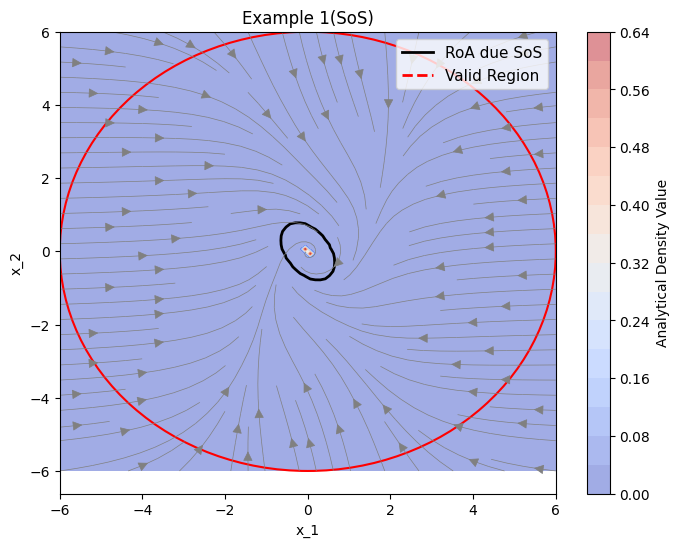

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Example 1(SoS)'}, xlabel='x_1', ylabel='x_2'>)

In [35]:
print("Plotting Analytical Solution...")
plot_analytical_density_and_flow(1e-8,device, plot_flow=True)


In [32]:

# --- 3. Function to plot Mixed (Learned + Analytical) Density and Flow ---

def plot_mixed_learned_analytical_contours(a_nn, b_nn, c_nn, a_nn1, b_nn1, c_nn1, device, analytical_weight=1.0, plot_flow=True):
    """ 
    Plots the contours of a mixed density (Learned + Analytical) and 
    the flow field of the corresponding mixed control policy.
    """
    # create meshgrid
    x1 = torch.linspace(-6, 6, 100)
    x2 = torch.linspace(-6, 6, 100)
    X, Y = np.meshgrid(x1,x2)
    
    # Convert to torch tensor
    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), dtype=torch.float32).to(device)
    
    # compute the modified density function
    with torch.no_grad():
        # rho_1 (Learned)
        rho_set1 = a_nn(grid_points) / (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)))
        
        # rho_2 (Analytical)
        rho_set2 = analytical_density(grid_points, device).unsqueeze(1) # Ensure shape [N, 1]

        rho_set3 = 10 * a_nn1(grid_points) / (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_nn1(grid_points))**2, dim=1, keepdim=True)))
        
        # rho_mixed = rho_1 + weight * rho_2
        rho_set = rho_set1 + analytical_weight * rho_set2 + rho_set3
        
        rho_set = rho_set.squeeze()
        rho_set = rho_set.cpu().numpy().reshape(X.shape)
        
    # plot the density function
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.contour(X,Y,rho_set-1e-8,levels=0,colors='black', linewidths=2,linestyles='solid', label='Mixed Density + Lyapunov ')
    filled_contours = ax.contourf(X, Y, rho_set, levels=20, alpha=0.3, cmap=cm.coolwarm)
    plt.colorbar(filled_contours, label='Mixed Density Value')
    
    if plot_flow:
        # create coarser grid for flow field
        x1_flow = np.linspace(-6, 6, 20)
        x2_flow = np.linspace(-6, 6, 20)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]), dtype=torch.float32).to(device)
        
        # evaluate control policy u
        with torch.no_grad():
            # rho_1 and u_1 (Learned)
            rho1_flow = a_nn(flow_points) / (torch.exp( torch.sum(flow_points**2, dim=1, keepdim=True) + torch.sum((b_nn(flow_points))**2, dim=1, keepdim=True)))
            u1_flow = c_nn(flow_points) / (a_nn(flow_points) ) # Add epsilon
            
            # rho_2 and u_2 (Analytical)
            rho2_flow = analytical_density(flow_points, device).unsqueeze(1) # Shape [N, 1]
            u2_flow = analytical_control(flow_points, device).unsqueeze(1)   # Shape [N, 1]

            rho3_flow = 10 * a_nn1(flow_points) / (torch.exp( torch.sum(flow_points**2, dim=1, keepdim=True) + torch.sum((b_nn1(flow_points))**2, dim=1, keepdim=True)))
            u3_flow = c_nn1(flow_points) / (a_nn1(flow_points) ) # Add epsilon

            # Weighted densities
            rho1_weighted = rho1_flow
            rho2_weighted = analytical_weight * rho2_flow
            rho3_weighted = rho3_flow
            
            # Total mixed density
            total_rho = rho1_weighted + rho2_weighted + rho3_weighted  # Add epsilon
            
            # Calculate weights
            weight1 = rho1_weighted / total_rho
            weight2 = rho2_weighted / total_rho
            weight3 = rho3_weighted / total_rho
            
            # Mixed control policy: u = w1*u1 + w2*u2
            u_values = weight1 * u1_flow + weight2 * u2_flow + weight3 * u3_flow
                                    
            # Calculate vector field
            DX = np.zeros_like(X_flow)
            DY = np.zeros_like(Y_flow)
            
            for i in range(len(x1_flow)):
                for j in range(len(x2_flow)):
                    idx = i * len(x1_flow) + j # Corrected index calculation
                    x_tensor = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device, dtype=torch.float32)

                    f_val = f(x_tensor)
                    g_val = g(x_tensor)
                    u = u_values[idx]
                    
                    # Compute flow: f(x) + g(x)u
                    flow = f_val + g_val * u
                    DX[i, j] = flow[0].cpu().numpy()
                    DY[i, j] = flow[1].cpu().numpy()
                    
            # Normalize vectors for better visualization
            magnitude = np.sqrt(DX**2 + DY**2) + 1e-9 # Avoid division by zero
            DX_norm = DX / magnitude
            DY_norm = DY / magnitude
            
            # Plot flow field
            ax.streamplot(X_flow, Y_flow, DX_norm, DY_norm, color='gray', linewidth=0.5,
                          density=1.0, arrowstyle='-|>', arrowsize=1.5)
            
    # Add valid region circle
    circle = plt.Circle((0, 0), 6, color='r', fill=False, linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)
    
        # Customize plot
    ax.set_xlabel('x_1')
    ax.set_ylabel('x_2')
    ax.set_title(f'Example 1(Mixed Density + SoS)')
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='RoA due to mixed density + SoS'),
        Line2D([0], [0], color='red', linewidth=2, linestyle='--', label='Valid Region')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    
    
    plt.show()
    return fig, ax


/tmp/ipykernel_3711846/2777224366.py:34: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X,Y,rho_set-1e-8,levels=0,colors='black', linewidths=2,linestyles='solid', label='Mixed Density + Lyapunov ')


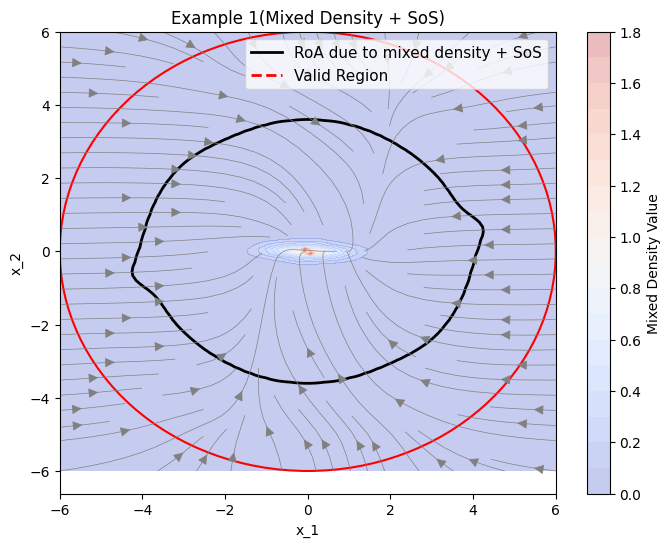

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Example 1(Mixed Density + SoS)'}, xlabel='x_1', ylabel='x_2'>)

In [33]:
plot_mixed_learned_analytical_contours( a_net, b_net, c_net, a_net1, b_net1, c_net1, device, analytical_weight=1.0, plot_flow=True)